In [1]:
# ============================================================
# RANDOM FOREST CLASSIFICATION FROM SCRATCH
# ============================================================
#
# This program demonstrates:
#
# 1. Dataset generation
# 2. Bootstrap sampling
# 3. Gini impurity
# 4. Random feature selection
# 5. Finding the best split
# 6. Building a decision tree
# 7. Building multiple trees
# 8. Majority voting
# 9. Random Forest prediction
# 10. Accuracy and confusion matrix
# 11. Visualization
#
# ============================================================


import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [2]:
# ============================================================
# 1. GENERATE DATASET
# ============================================================

X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=42
)

In [3]:
# ============================================================
# 2. SPLIT DATA INTO TRAINING AND TESTING DATA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 210
Testing samples : 90


In [4]:
# ============================================================
# 3. GINI IMPURITY
# ============================================================
#
# Gini impurity measures how mixed the classes are
# inside a node.
#
# Formula:
#
#       Gini = 1 - sum(p_k^2)
#
# where:
#
#       p_k = proportion of samples belonging to class k
#
# Pure node:
#
#       Gini = 0
#
# ============================================================

def gini_impurity(y):

    # If there are no samples
    if len(y) == 0:
        return 0

    # Find unique classes
    classes, counts = np.unique(
        y,
        return_counts=True
    )

    # Calculate probability of each class
    probabilities = counts / len(y)

    # Gini impurity
    gini = 1 - np.sum(probabilities ** 2)

    return gini


In [5]:
# ============================================================
# 4. CALCULATE GINI IMPURITY AFTER A SPLIT
# ============================================================

def split_gini(y_left, y_right):

    total_samples = len(y_left) + len(y_right)

    # Gini of left node
    gini_left = gini_impurity(y_left)

    # Gini of right node
    gini_right = gini_impurity(y_right)

    # Weighted Gini
    weighted_gini = (
        (len(y_left) / total_samples) * gini_left
        +
        (len(y_right) / total_samples) * gini_right
    )

    return weighted_gini

In [6]:
# ============================================================
# 5. SPLIT DATA
# ============================================================

def split_dataset(X, y, feature, threshold):

    # Samples going to left child
    left_mask = X[:, feature] <= threshold

    # Samples going to right child
    right_mask = X[:, feature] > threshold

    X_left = X[left_mask]
    y_left = y[left_mask]

    X_right = X[right_mask]
    y_right = y[right_mask]

    return X_left, y_left, X_right, y_right

In [7]:
# ============================================================
# 6. FIND BEST SPLIT
# ============================================================

def find_best_split(X, y, feature_indices):

    best_feature = None
    best_threshold = None

    best_gini = float("inf")


    # Examine only randomly selected features
    for feature in feature_indices:

        # Get possible threshold values
        thresholds = np.unique(
            X[:, feature]
        )


        # Try every possible threshold
        for threshold in thresholds:

            # Split dataset
            X_left, y_left, X_right, y_right = \
                split_dataset(
                    X,
                    y,
                    feature,
                    threshold
                )


            # Ignore invalid splits
            if len(y_left) == 0 or len(y_right) == 0:
                continue


            # Calculate Gini after split
            gini = split_gini(
                y_left,
                y_right
            )


            # Keep the best split
            if gini < best_gini:

                best_gini = gini

                best_feature = feature

                best_threshold = threshold


    return (
        best_feature,
        best_threshold,
        best_gini
    )


In [8]:
# ============================================================
# 7. DECISION TREE NODE
# ============================================================

class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        prediction=None
    ):

        # Feature used for splitting
        self.feature = feature

        # Threshold used for splitting
        self.threshold = threshold

        # Left child
        self.left = left

        # Right child
        self.right = right

        # Prediction stored in leaf
        self.prediction = prediction


In [9]:
# ============================================================
# 8. BUILD DECISION TREE
# ============================================================

def build_tree(
    X,
    y,
    depth=0,
    max_depth=5,
    min_samples_split=2,
    max_features=None
):

    # --------------------------------------------------------
    # STOPPING CONDITION 1:
    # All samples belong to the same class
    # --------------------------------------------------------

    if len(np.unique(y)) == 1:

        return Node(
            prediction=y[0]
        )


    # --------------------------------------------------------
    # STOPPING CONDITION 2:
    # Maximum tree depth reached
    # --------------------------------------------------------

    if depth >= max_depth:

        prediction = np.bincount(y).argmax()

        return Node(
            prediction=prediction
        )


    # --------------------------------------------------------
    # STOPPING CONDITION 3:
    # Too few samples
    # --------------------------------------------------------

    if len(y) < min_samples_split:

        prediction = np.bincount(y).argmax()

        return Node(
            prediction=prediction
        )


    # --------------------------------------------------------
    # RANDOM FEATURE SELECTION
    # --------------------------------------------------------

    n_features = X.shape[1]


    if max_features is None:

        max_features = int(
            np.sqrt(n_features)
        )


    # Randomly select features
    feature_indices = np.random.choice(
        n_features,
        size=max_features,
        replace=False
    )


    # --------------------------------------------------------
    # FIND BEST SPLIT
    # --------------------------------------------------------

    feature, threshold, gini = \
        find_best_split(
            X,
            y,
            feature_indices
        )


    # If no valid split exists
    if feature is None:

        prediction = np.bincount(y).argmax()

        return Node(
            prediction=prediction
        )


    # --------------------------------------------------------
    # SPLIT DATA USING BEST FEATURE
    # --------------------------------------------------------

    X_left, y_left, X_right, y_right = \
        split_dataset(
            X,
            y,
            feature,
            threshold
        )


    # --------------------------------------------------------
    # RECURSIVELY BUILD LEFT TREE
    # --------------------------------------------------------

    left_child = build_tree(
        X_left,
        y_left,
        depth + 1,
        max_depth,
        min_samples_split,
        max_features
    )


    # --------------------------------------------------------
    # RECURSIVELY BUILD RIGHT TREE
    # --------------------------------------------------------

    right_child = build_tree(
        X_right,
        y_right,
        depth + 1,
        max_depth,
        min_samples_split,
        max_features
    )


    # --------------------------------------------------------
    # CREATE INTERNAL NODE
    # --------------------------------------------------------

    return Node(
        feature=feature,
        threshold=threshold,
        left=left_child,
        right=right_child
    )



In [10]:
# ============================================================
# 9. PREDICT USING ONE DECISION TREE
# ============================================================

def predict_tree(node, x):

    # --------------------------------------------------------
    # If this is a leaf node
    # --------------------------------------------------------

    if node.prediction is not None:

        return node.prediction


    # --------------------------------------------------------
    # Follow left branch
    # --------------------------------------------------------

    if x[node.feature] <= node.threshold:

        return predict_tree(
            node.left,
            x
        )


    # --------------------------------------------------------
    # Follow right branch
    # --------------------------------------------------------

    else:

        return predict_tree(
            node.right,
            x
        )


# ============================================================
# 10. BOOTSTRAP SAMPLING
# ============================================================
#
# Each decision tree receives a randomly sampled dataset.
#
# Sampling is performed WITH replacement.
#
# Therefore, some samples may occur multiple times while
# some original samples may not appear in a particular tree.
#
# ============================================================

def bootstrap_sample(X, y):

    n_samples = len(X)

    indices = np.random.choice(
        n_samples,
        size=n_samples,
        replace=True
    )

    return X[indices], y[indices]



Training Random Forest...

Tree 1 created
Tree 2 created
Tree 3 created
Tree 4 created
Tree 5 created
Tree 6 created
Tree 7 created
Tree 8 created
Tree 9 created
Tree 10 created

Random Forest Accuracy:
93.33 %

Confusion Matrix:
[[42  4]
 [ 2 42]]


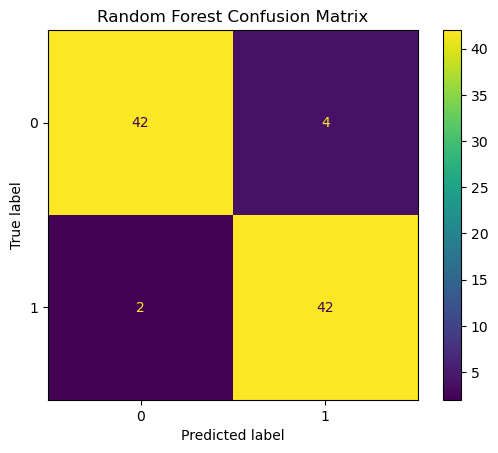

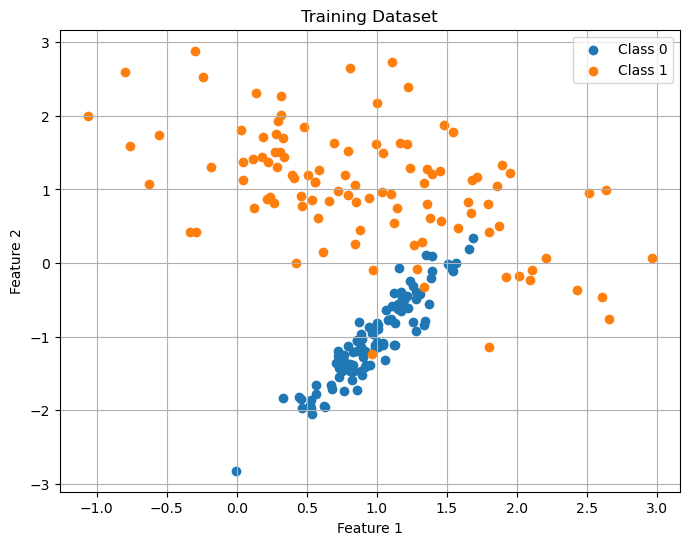

In [11]:
# ============================================================
# 11. RANDOM FOREST TRAINING
# ============================================================

def train_random_forest(
    X,
    y,
    n_trees=10,
    max_depth=5,
    max_features=None
):

    forest = []


    print("\nTraining Random Forest...\n")


    # --------------------------------------------------------
    # Build multiple decision trees
    # --------------------------------------------------------

    for tree_number in range(n_trees):

        # Bootstrap sample
        X_sample, y_sample = \
            bootstrap_sample(
                X,
                y
            )


        # Build decision tree
        tree = build_tree(
            X_sample,
            y_sample,
            max_depth=max_depth,
            max_features=max_features
        )


        # Store tree
        forest.append(tree)


        print(
            "Tree",
            tree_number + 1,
            "created"
        )


    return forest


# ============================================================
# 12. RANDOM FOREST PREDICTION
# ============================================================
#
# Every tree produces a prediction.
#
# Example:
#
# Tree 1 → Class 0
# Tree 2 → Class 1
# Tree 3 → Class 1
# Tree 4 → Class 1
# Tree 5 → Class 0
#
# Class 1 receives 3 votes.
# Class 0 receives 2 votes.
#
# Final prediction = Class 1
#
# ============================================================

def predict_forest(forest, X):

    predictions = []


    for x in X:

        # Obtain prediction from every tree
        tree_predictions = []

        for tree in forest:

            prediction = predict_tree(
                tree,
                x
            )

            tree_predictions.append(
                prediction
            )


        # Majority voting
        classes, counts = np.unique(
            tree_predictions,
            return_counts=True
        )


        # Select class with maximum votes
        final_prediction = classes[
            np.argmax(counts)
        ]


        predictions.append(
            final_prediction
        )


    return np.array(predictions)


# ============================================================
# 13. TRAIN RANDOM FOREST
# ============================================================

np.random.seed(42)

forest = train_random_forest(
    X_train,
    y_train,
    n_trees=10,
    max_depth=5,
    max_features=1
)


# ============================================================
# 14. PREDICT TEST DATA
# ============================================================

y_pred = predict_forest(
    forest,
    X_test
)


# ============================================================
# 15. CALCULATE ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nRandom Forest Accuracy:")
print(
    round(accuracy * 100, 2),
    "%"
)


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 17. VISUALIZE CONFUSION MATRIX
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()


# ============================================================
# 18. VISUALIZE DATASET
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    label="Class 0"
)

plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    label="Class 1"
)

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title(
    "Training Dataset"
)

plt.legend()

plt.grid(True)

plt.show()

In [12]:
# ============================================================
# VISUALIZE ONE DECISION TREE
# ============================================================

def print_tree(node, depth=0, branch="ROOT"):

    # Create indentation based on tree depth
    indent = "    " * depth

    # --------------------------------------------------------
    # LEAF NODE
    # --------------------------------------------------------

    if node.prediction is not None:

        print(
            indent
            + branch
            + " → LEAF: Class "
            + str(node.prediction)
        )

        return


    # --------------------------------------------------------
    # INTERNAL NODE
    # --------------------------------------------------------

    print(
        indent
        + branch
        + " → Feature "
        + str(node.feature)
        + " <= "
        + str(round(node.threshold, 3))
    )


    # --------------------------------------------------------
    # LEFT SUBTREE
    # --------------------------------------------------------

    print_tree(
        node.left,
        depth + 1,
        "YES"
    )


    # --------------------------------------------------------
    # RIGHT SUBTREE
    # --------------------------------------------------------

    print_tree(
        node.right,
        depth + 1,
        "NO"
    )

In [13]:
# ============================================================
# DISPLAY THE FIRST TREE
# ============================================================

print("\n===================================")
print("TREE 1")
print("===================================")

print_tree(forest[0])


TREE 1
ROOT → Feature 1 <= 0.005
    YES → Feature 1 <= -0.244
        YES → Feature 0 <= 1.342
            YES → Feature 0 <= 1.307
                YES → Feature 0 <= 0.954
                    YES → LEAF: Class 0
                    NO → LEAF: Class 0
                NO → Feature 0 <= 1.336
                    YES → LEAF: Class 1
                    NO → LEAF: Class 0
            NO → LEAF: Class 1
        NO → Feature 1 <= -0.181
            YES → LEAF: Class 1
            NO → Feature 0 <= 1.289
                YES → LEAF: Class 1
                NO → Feature 1 <= -0.094
                    YES → LEAF: Class 0
                    NO → LEAF: Class 0
    NO → Feature 0 <= 1.391
        YES → LEAF: Class 1
        NO → Feature 1 <= 0.334
            YES → Feature 0 <= 1.687
                YES → LEAF: Class 0
                NO → LEAF: Class 1
            NO → LEAF: Class 1


Training samples: 210
Testing samples : 90

Training Random Forest...
--------------------------------
Tree 1 created
Tree 2 created
Tree 3 created
Tree 4 created
Tree 5 created
Tree 6 created
Tree 7 created
Tree 8 created
Tree 9 created
Tree 10 created

RANDOM FOREST RESULTS
Accuracy: 93.33 %

Confusion Matrix:
[[43  3]
 [ 3 41]]


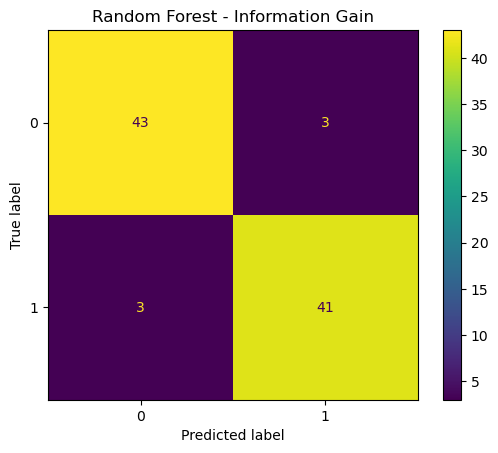

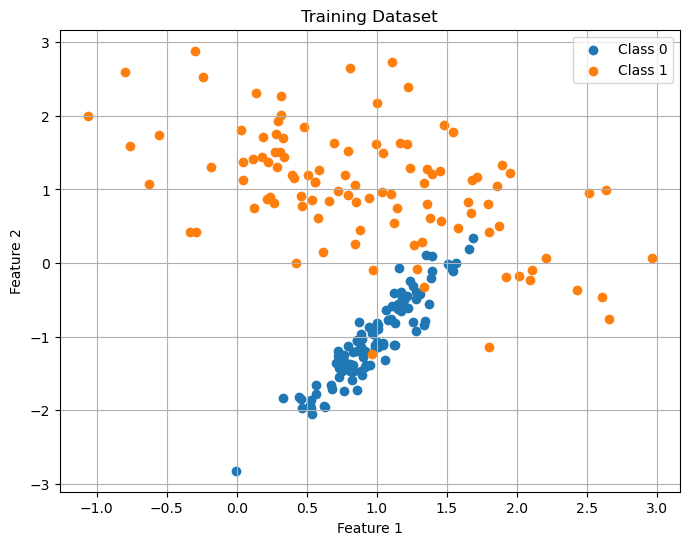

In [14]:
# ============================================================
# RANDOM FOREST CLASSIFICATION USING INFORMATION GAIN
# ============================================================
#
# RANDOM FOREST =
#
#   Bootstrap Sampling
#          +
#   Random Feature Selection
#          +
#   Decision Trees
#          +
#   Information Gain
#          +
#   Majority Voting
#
# ============================================================


import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


# ============================================================
# 1. CREATE DATASET
# ============================================================

X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=42
)


# ============================================================
# 2. SPLIT DATASET
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 3. ENTROPY
# ============================================================
#
# Entropy measures the impurity / uncertainty in a node.
#
# Formula:
#
#       H(S) = - Σ p_k log2(p_k)
#
# For binary classification:
#
#       H(S)
#       = -p0 log2(p0) - p1 log2(p1)
#
#
# Pure node:
#
#       [Class 0, Class 0, Class 0]
#
#       Entropy = 0
#
#
# Completely mixed binary node:
#
#       [Class 0, Class 1]
#
#       Entropy = 1
#
# ============================================================

def entropy(y):

    # If the node contains no samples,
    # entropy is defined as zero.
    if len(y) == 0:
        return 0


    # Find unique classes and their frequencies
    classes, counts = np.unique(
        y,
        return_counts=True
    )


    # Convert frequencies into probabilities
    probabilities = counts / len(y)


    # Initialize entropy
    entropy_value = 0


    # Calculate:
    #
    #       -Σ p log2(p)
    #
    for p in probabilities:

        # p > 0 prevents log2(0)
        if p > 0:

            entropy_value -= p * np.log2(p)


    return entropy_value


# ============================================================
# 4. INFORMATION GAIN
# ============================================================
#
# Information Gain tells us how much uncertainty is reduced
# after performing a split.
#
# Formula:
#
# IG = Entropy(parent)
#      -
#      Weighted Entropy(children)
#
# ============================================================

def information_gain(y_parent, y_left, y_right):

    # Total number of samples
    total_samples = len(y_parent)


    # Entropy before splitting
    parent_entropy = entropy(y_parent)


    # Entropy of left child
    left_entropy = entropy(y_left)


    # Entropy of right child
    right_entropy = entropy(y_right)


    # Weighted entropy after splitting
    weighted_child_entropy = (
        (len(y_left) / total_samples) * left_entropy
        +
        (len(y_right) / total_samples) * right_entropy
    )


    # Information Gain
    gain = (
        parent_entropy
        -
        weighted_child_entropy
    )


    return gain


# ============================================================
# 5. SPLIT DATASET
# ============================================================

def split_dataset(
    X,
    y,
    feature,
    threshold
):

    # Samples satisfying:
    #
    #       X(feature) <= threshold
    #
    # go to the left child.

    left_mask = (
        X[:, feature] <= threshold
    )


    # Samples satisfying:
    #
    #       X(feature) > threshold
    #
    # go to the right child.

    right_mask = (
        X[:, feature] > threshold
    )


    # Left child
    X_left = X[left_mask]
    y_left = y[left_mask]


    # Right child
    X_right = X[right_mask]
    y_right = y[right_mask]


    return (
        X_left,
        y_left,
        X_right,
        y_right
    )


# ============================================================
# 6. FIND BEST SPLIT USING INFORMATION GAIN
# ============================================================

def find_best_split(
    X,
    y,
    feature_indices
):

    best_feature = None

    best_threshold = None

    best_gain = -float("inf")


    # --------------------------------------------------------
    # Examine only randomly selected features
    # --------------------------------------------------------

    for feature in feature_indices:


        # Get unique values of the feature
        thresholds = np.unique(
            X[:, feature]
        )


        # ----------------------------------------------------
        # Try each possible threshold
        # ----------------------------------------------------

        for threshold in thresholds:


            # Split dataset
            (
                X_left,
                y_left,
                X_right,
                y_right
            ) = split_dataset(
                X,
                y,
                feature,
                threshold
            )


            # Ignore invalid splits
            if (
                len(y_left) == 0
                or
                len(y_right) == 0
            ):
                continue


            # ------------------------------------------------
            # Calculate Information Gain
            # ------------------------------------------------

            gain = information_gain(
                y,
                y_left,
                y_right
            )


            # ------------------------------------------------
            # Select maximum Information Gain
            # ------------------------------------------------

            if gain > best_gain:

                best_gain = gain

                best_feature = feature

                best_threshold = threshold


    return (
        best_feature,
        best_threshold,
        best_gain
    )


# ============================================================
# 7. DECISION TREE NODE
# ============================================================

class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        prediction=None,
        gain=None
    ):

        # Feature used for splitting
        self.feature = feature


        # Threshold used for splitting
        self.threshold = threshold


        # Left child
        self.left = left


        # Right child
        self.right = right


        # Prediction stored at leaf
        self.prediction = prediction


        # Information Gain of this split
        self.gain = gain


# ============================================================
# 8. BUILD DECISION TREE
# ============================================================

def build_tree(
    X,
    y,
    depth=0,
    max_depth=5,
    min_samples_split=2,
    max_features=None
):


    # ========================================================
    # STOPPING CONDITION 1
    # ========================================================
    #
    # If all samples belong to the same class,
    # there is no need for further splitting.
    #

    if len(np.unique(y)) == 1:

        return Node(
            prediction=y[0]
        )


    # ========================================================
    # STOPPING CONDITION 2
    # ========================================================
    #
    # Stop when maximum depth is reached.
    #

    if depth >= max_depth:

        prediction = np.bincount(y).argmax()

        return Node(
            prediction=prediction
        )


    # ========================================================
    # STOPPING CONDITION 3
    # ========================================================
    #
    # Stop if there are too few samples.
    #

    if len(y) < min_samples_split:

        prediction = np.bincount(y).argmax()

        return Node(
            prediction=prediction
        )


    # ========================================================
    # RANDOM FEATURE SELECTION
    # ========================================================

    n_features = X.shape[1]


    # If max_features is not specified,
    # use sqrt(number of features).
    if max_features is None:

        max_features = max(
            1,
            int(np.sqrt(n_features))
        )


    # Randomly select features
    feature_indices = np.random.choice(
        n_features,
        size=max_features,
        replace=False
    )


    # ========================================================
    # FIND BEST SPLIT
    # ========================================================

    (
        feature,
        threshold,
        gain
    ) = find_best_split(
        X,
        y,
        feature_indices
    )


    # ========================================================
    # IF NO VALID SPLIT EXISTS
    # ========================================================

    if feature is None:

        prediction = np.bincount(y).argmax()

        return Node(
            prediction=prediction
        )


    # ========================================================
    # SPLIT DATA
    # ========================================================

    (
        X_left,
        y_left,
        X_right,
        y_right
    ) = split_dataset(
        X,
        y,
        feature,
        threshold
    )


    # ========================================================
    # BUILD LEFT SUBTREE
    # ========================================================

    left_child = build_tree(
        X_left,
        y_left,
        depth=depth + 1,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features
    )


    # ========================================================
    # BUILD RIGHT SUBTREE
    # ========================================================

    right_child = build_tree(
        X_right,
        y_right,
        depth=depth + 1,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features
    )


    # ========================================================
    # CREATE CURRENT TREE NODE
    # ========================================================

    return Node(
        feature=feature,
        threshold=threshold,
        left=left_child,
        right=right_child,
        gain=gain
    )


# ============================================================
# 9. PREDICT USING ONE TREE
# ============================================================

def predict_tree(node, x):


    # --------------------------------------------------------
    # If leaf node, return prediction
    # --------------------------------------------------------

    if node.prediction is not None:

        return node.prediction


    # --------------------------------------------------------
    # Follow LEFT branch
    # --------------------------------------------------------

    if x[node.feature] <= node.threshold:

        return predict_tree(
            node.left,
            x
        )


    # --------------------------------------------------------
    # Follow RIGHT branch
    # --------------------------------------------------------

    else:

        return predict_tree(
            node.right,
            x
        )


# ============================================================
# 10. BOOTSTRAP SAMPLING
# ============================================================
#
# Random Forest creates a different training dataset for
# every tree.
#
# Sampling is performed WITH REPLACEMENT.
#
# ============================================================

def bootstrap_sample(X, y):

    n_samples = len(X)


    # Random indices with replacement
    indices = np.random.choice(
        n_samples,
        size=n_samples,
        replace=True
    )


    return (
        X[indices],
        y[indices]
    )


# ============================================================
# 11. TRAIN RANDOM FOREST
# ============================================================

def train_random_forest(
    X,
    y,
    n_trees=10,
    max_depth=5,
    max_features=None
):

    forest = []


    print("\nTraining Random Forest...")
    print("--------------------------------")


    # --------------------------------------------------------
    # Create multiple decision trees
    # --------------------------------------------------------

    for tree_number in range(n_trees):


        # ----------------------------------------------------
        # Step 1:
        # Create bootstrap dataset
        # ----------------------------------------------------

        (
            X_sample,
            y_sample
        ) = bootstrap_sample(
            X,
            y
        )


        # ----------------------------------------------------
        # Step 2:
        # Build decision tree
        # ----------------------------------------------------

        tree = build_tree(
            X_sample,
            y_sample,
            max_depth=max_depth,
            max_features=max_features
        )


        # ----------------------------------------------------
        # Step 3:
        # Store tree
        # ----------------------------------------------------

        forest.append(tree)


        print(
            "Tree",
            tree_number + 1,
            "created"
        )


    return forest


# ============================================================
# 12. RANDOM FOREST PREDICTION
# ============================================================
#
# Each tree produces one prediction.
#
# Example:
#
# Tree 1 → Class 0
# Tree 2 → Class 1
# Tree 3 → Class 1
# Tree 4 → Class 1
# Tree 5 → Class 0
#
# Class 1 receives 3 votes.
# Class 0 receives 2 votes.
#
# Final prediction = Class 1
#
# ============================================================

def predict_forest(
    forest,
    X
):

    predictions = []


    # Process every test sample
    for x in X:


        # Predictions from all trees
        tree_predictions = []


        for tree in forest:

            prediction = predict_tree(
                tree,
                x
            )

            tree_predictions.append(
                prediction
            )


        # ----------------------------------------------------
        # MAJORITY VOTING
        # ----------------------------------------------------

        classes, counts = np.unique(
            tree_predictions,
            return_counts=True
        )


        # Class with maximum votes
        final_prediction = classes[
            np.argmax(counts)
        ]


        predictions.append(
            final_prediction
        )


    return np.array(
        predictions
    )


# ============================================================
# 13. TRAIN RANDOM FOREST
# ============================================================

np.random.seed(42)


forest = train_random_forest(
    X_train,
    y_train,
    n_trees=10,
    max_depth=5,
    max_features=1
)


# ============================================================
# 14. PREDICT TEST DATA
# ============================================================

y_pred = predict_forest(
    forest,
    X_test
)


# ============================================================
# 15. CALCULATE ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)


print("\n===================================")
print("RANDOM FOREST RESULTS")
print("===================================")

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 17. DISPLAY CONFUSION MATRIX
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Random Forest - Information Gain"
)

plt.show()


# ============================================================
# 18. VISUALIZE TRAINING DATA
# ============================================================

plt.figure(
    figsize=(8, 6)
)


# Class 0
plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    label="Class 0"
)


# Class 1
plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    label="Class 1"
)


plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title(
    "Training Dataset"
)

plt.legend()

plt.grid(True)

plt.show()